# Estudo de Cinética de Reação de Primeira Ordem

Neste notebook, analisaremos experimentalmente a cinética de uma reação de primeira ordem usando dados de absorvância (UV-Vis).

#### 1️⃣ Introdução Teórica

Para uma reação de primeira ordem:

$$A \longrightarrow produtos$$

A velocidade é dada por:

$$v = -\frac{d[A]}{dt} = k[A]$$

Integrando, obtemos a forma linear:

$$ \int_{[A]_0}^{[A]} \frac{d[A]}{[A]} = -\int_{t=0}^{t} k \; dt \Rightarrow \boxed{\ln\left(\frac{[A]}{[A]_0}\right) = -kt}$$

Portanto, plotando $\ln\left(\frac{[A]}{[A]_0}\right)$ vs. $t$, obtemos uma reta de declive $-k$.

### 2️⃣ Leitura dos dados experimentais

In [13]:
import pandas as pd

df_data = pd.read_csv('data.csv')
df_data.head()

,t,abs
0,0,1.05
1,20,0.75
2,40,0.40
3,60,0.32
4,80,0.10


### 3️⃣ Cálculo da absorvância relativa e logaritmo natural

In [14]:
import numpy as np

# Valor inicial da absorvância
A0 = df_data['abs'].iloc[0]

# Cálculo da absorvância relativa e logaritmo natural
df_data['abs/abs0'] = df_data['abs'] / A0
df_data['ln'] = np.log(df_data['abs/abs0'])

df_data.head()

,t,abs,abs/abs0,ln
0,0,1.05,1.000000,0.000000
1,20,0.75,0.714286,-0.336472
2,40,0.40,0.380952,-0.965081
3,60,0.32,0.304762,-1.188224
4,80,0.10,0.095238,-2.351375


### 4️⃣ Plotagem do gráfico de primeira ordem

<Axes: title={'center': 'Reação de primeira ordem'}, xlabel='Tempo (s)', ylabel='$ln([A]/[A]_0)$'>

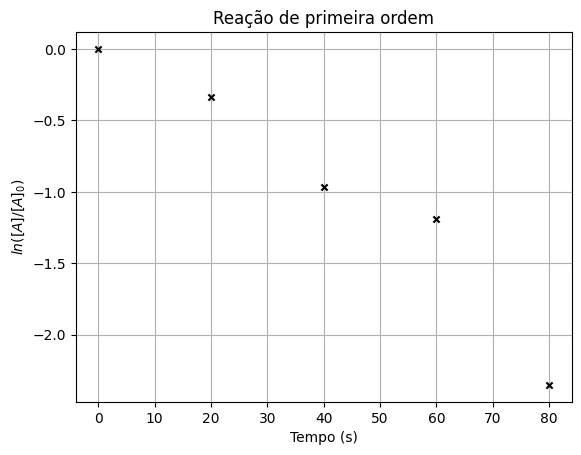

In [15]:
df_data.plot(x='t', y='ln', kind='scatter', title='Reação de primeira ordem', grid=True, xlabel='Tempo (s)', ylabel='$ln([A]/[A]_0)$', marker='x', color='black', zorder=3)

### 5️⃣ Cálculo da constante de velocidade $k$ via regressão linear

Lembre-se que $k=-m$

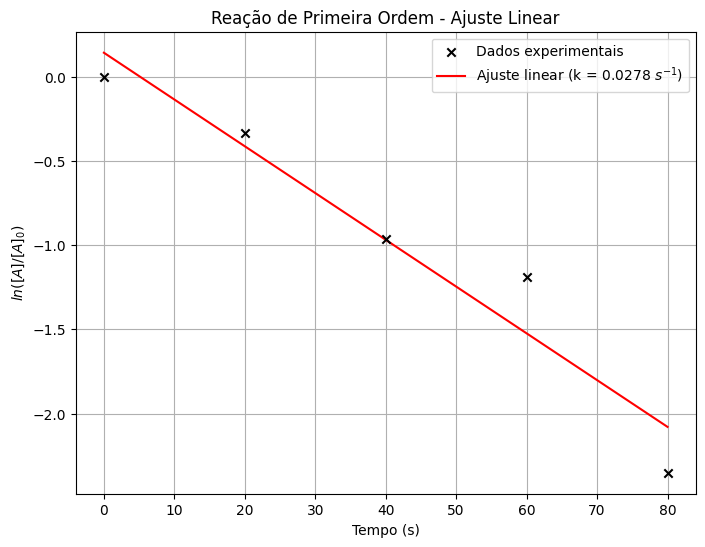

Slope: -0.027772513625317696 
Intercept: 0.14266997757549293 
k = 0.027772513625317696 
R^2 = 0.9354669763406579 
p = 0.007097199107480631


In [16]:
from matplotlib import pyplot as plt
from scipy import stats

# Regressão linear
df_regression = df_data[['t','ln']].copy()

m, b, r, p, se = stats.linregress(df_regression['t'], df_regression['ln'])
df_regression['fx'] = (m*df_regression['t']) + b
R = r**2

# Cálculo da constante de velocidade
k = -m

# Plot dos dados
plt.figure(figsize=(8,6))
plt.scatter(df_regression['t'], df_regression['ln'], color='black', marker='x', zorder=4, label='Dados experimentais')
plt.plot(df_regression['t'], df_regression['fx'], color='red', zorder=3, label=f'Ajuste linear (k = {k:.4f} $s^{{-1}}$)')

plt.title('Reação de Primeira Ordem - Ajuste Linear')
plt.xlabel('Tempo (s)')
plt.ylabel('$ln([A]/[A]_0)$')
plt.grid(True)
plt.legend()  
plt.show()

print(f"Slope: {m} \nIntercept: {b} \nk = {k} \nR^2 = {R} \np = {p}")